# 11 — Sintesis dual: consolidacion de hallazgos y cobertura de objetivos

**Proposito.** Consolidar los hallazgos de los diez cuadernos anteriores en una tabla maestra con
etiquetado dual, cuantificar la distribucion de etiquetas, evaluar que objetivo de cada uno de los dos
trabajos de grado queda cubierto por este EDA, y generar el documento
`docs/HALLAZGOS_ETIQUETADOS.md`.

**Insumo.** Los archivos `data/hallazgos_NN.csv` producidos por cada cuaderno.

**Etiquetas de objetivo que atiende:** todas.

---

## Declaracion de autoria y significado del etiquetado dual

Este EDA es un unico ejercicio tecnico de autoria de **Andres Telles**. Todo el codigo de
`eda-extendido-integral/` es propio. El dataset integrado de entrada proviene del pipeline compartido
(`notebooks/00-06`), cuya autoria sigue pendiente de confirmacion con el director
(`InformesRev/MATRIZ_OBJETIVOS_CODIGO.md`, tarea de prioridad 1), y asi se declara en el notebook 01.
Las columnas producidas por el codigo excluido del blindaje se eliminan fisicamente del DataFrame de
trabajo antes de cualquier analisis y no se leen en ningun punto.

El etiquetado dual clasifica cada hallazgo segun **a que objetivo sirve**, incluidos los objetivos del
compañero:

| Etiqueta | Significado exacto |
|---|---|
| `[A-OE02]` `[A-OE03]` `[A-OE04]` | Sirve a ese objetivo especifico de Andres Telles |
| `[A-H1]` `[A-H2]` `[A-H3]` | Aporta evidencia a esa hipotesis de Andres Telles |
| `[B-OE2]` | **Le seria util** al objetivo de EDA del compañero (Angel Garcia) |
| `[B-OE3-insumo]` | Identifica una variable con asociacion relevante que **seria** candidata predictora. Es informacion sobre asociacion, no modelado |
| `[CALIDAD]` | Hallazgo sobre la calidad del dato SECOP en si mismo, citable por cualquiera de los dos trabajos |

**Regla de honestidad, escrita de forma explicita.** Una etiqueta `[B-*]` significa "este hallazgo le
seria util al compañero". **No** significa "este hallazgo es del compañero", **no** significa que el
compañero lo haya producido, y **no** significa que Andres Telles haya trabajado para el compañero. La
utilidad cruzada de un hallazgo no transfiere su autoria. Ningun resultado de este EDA se ha producido
con codigo del compañero, y ningun resultado de este EDA se atribuye al compañero.

In [1]:
import sys
from pathlib import Path

_p = Path.cwd()
BASE_EDA = _p.parent if _p.name == "notebooks" else _p
sys.path.insert(0, str(BASE_EDA / "src"))

import numpy as np
import pandas as pd
from scipy import stats
from eda_comun import *

plt, CMAP_SEQ, CMAP_DIV = configurar_matplotlib()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Modulo propio eda_comun cargado desde:", BASE_EDA / "src")
print("Alfa declarado a priori:", ALFA)

Modulo propio eda_comun cargado desde: /home/william-telles/Documentos/extraccion-datos-secop2-main (1)/extraccion-datos-secop2-main/eda-extendido-integral/src
Alfa declarado a priori: 0.05


In [2]:
import glob

# Se excluye hallazgos_maestra.csv, que es producto de este mismo cuaderno: incluirlo
# duplicaria los registros al reejecutar.
archivos = [a for a in sorted(glob.glob(str(DIR_DATA / "hallazgos_*.csv")))
            if not Path(a).name.startswith("hallazgos_maestra")]
print("Archivos de hallazgos encontrados:", len(archivos))
for a in archivos:
    print("  ", Path(a).name)
maestra = pd.concat([pd.read_csv(a) for a in archivos], ignore_index=True)
maestra["notebook"] = maestra["notebook"].astype(str).str.zfill(2)
maestra = maestra.sort_values(["notebook", "id"]).reset_index(drop=True)
print()
print(f"Total de hallazgos consolidados: {len(maestra)}")
print(maestra.groupby("notebook").size().to_frame("hallazgos").to_string())

Archivos de hallazgos encontrados: 10
   hallazgos_01.csv
   hallazgos_02.csv
   hallazgos_03.csv
   hallazgos_04.csv
   hallazgos_05.csv
   hallazgos_06.csv
   hallazgos_07.csv
   hallazgos_08.csv
   hallazgos_09.csv
   hallazgos_10.csv

Total de hallazgos consolidados: 61
          hallazgos
notebook           
01                6
02                6
03                8
04                6
05                6
06                5
07                7
08                4
09                5
10                8


## 1. Distribucion de etiquetas

In [3]:
marcar("distribucion")

import re
todas = []
for e in maestra["etiquetas"]:
    todas.extend(re.findall(r"\[([^\]]+)\]", str(e)))
dist = pd.Series(todas).value_counts().to_frame("hallazgos")
dist["pct_de_los_hallazgos"] = (dist["hallazgos"] / len(maestra) * 100).round(1)
dist["bloque"] = np.where(dist.index.str.startswith("A-"), "Trabajo A (Andres Telles)",
                  np.where(dist.index.str.startswith("B-"), "Utilidad para el Trabajo B (compañero)",
                           "Calidad del dato SECOP"))
print(f"Total de asignaciones de etiqueta: {len(todas)} sobre {len(maestra)} hallazgos "
      f"(promedio {len(todas)/len(maestra):.2f} etiquetas por hallazgo)")
print()
print(dist.to_string())
print()
print("Hallazgos por bloque (un hallazgo puede contar en varios bloques):")
for bl in ["Trabajo A (Andres Telles)", "Utilidad para el Trabajo B (compañero)", "Calidad del dato SECOP"]:
    etqs = dist[dist["bloque"] == bl].index.tolist()
    n = int(maestra["etiquetas"].apply(lambda s: any(f"[{e}]" in str(s) for e in etqs)).sum())
    print(f"  {bl}: {n} hallazgos ({n/len(maestra)*100:.1f}%)")
print()
print("Distribucion por valor declarado:")
print(maestra["valor"].value_counts().to_frame("hallazgos").to_string())

Total de asignaciones de etiqueta: 132 sobre 61 hallazgos (promedio 2.16 etiquetas por hallazgo)

              hallazgos  pct_de_los_hallazgos                                  bloque
B-OE2                36               59.0000  Utilidad para el Trabajo B (compañero)
CALIDAD              28               45.9000                  Calidad del dato SECOP
A-OE03               23               37.7000               Trabajo A (Andres Telles)
B-OE3-insumo         20               32.8000  Utilidad para el Trabajo B (compañero)
A-H1                  8               13.1000               Trabajo A (Andres Telles)
A-OE04                8               13.1000               Trabajo A (Andres Telles)
A-OE02                4                6.6000               Trabajo A (Andres Telles)
A-H2                  4                6.6000               Trabajo A (Andres Telles)
A-H3                  1                1.6000               Trabajo A (Andres Telles)

Hallazgos por bloque (un hallazgo puede c

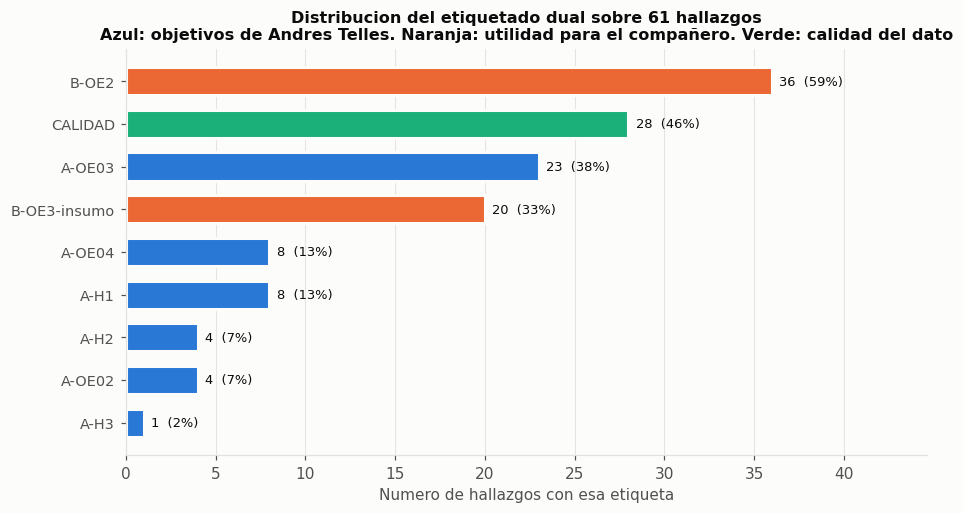

Figura persistida: 11_distribucion_etiquetas.png


In [4]:
marcar("fig_distribucion")

d = dist.sort_values("hallazgos")
colores = {"Trabajo A (Andres Telles)": PALETA[0],
           "Utilidad para el Trabajo B (compañero)": PALETA[1],
           "Calidad del dato SECOP": PALETA[2]}
fig, ax = plt.subplots(figsize=(9.4, 4.8))
ax.barh(range(len(d)), d["hallazgos"], color=[colores[b] for b in d["bloque"]],
        height=0.66, edgecolor=SURFACE, linewidth=2)
for i, (v, p) in enumerate(zip(d["hallazgos"], d["pct_de_los_hallazgos"])):
    ax.text(v + 0.4, i, f"{v}  ({p:.0f}%)", va="center", fontsize=8.5, color=TEXT_1)
ax.set_yticks(range(len(d))); ax.set_yticklabels(d.index, fontsize=9.5)
ax.set_xlabel("Numero de hallazgos con esa etiqueta")
ax.set_xlim(0, d["hallazgos"].max() * 1.24)
ax.set_title(f"Distribucion del etiquetado dual sobre {len(maestra)} hallazgos\n"
             "Azul: objetivos de Andres Telles. Naranja: utilidad para el compañero. Verde: calidad del dato",
             fontsize=10.5)
ax.yaxis.grid(False); ax.set_axisbelow(True)
guardar_mostrar(fig, "11_distribucion_etiquetas.png")

## 2. Tabla maestra de hallazgos

In [5]:
marcar("maestra")

maestra_out = maestra[["id", "notebook", "celda", "hallazgo", "etiquetas", "evidencia", "valor", "nota"]]
maestra_out.to_csv(DIR_DATA / "hallazgos_maestra.csv", index=False)
print(f"Tabla maestra persistida: {len(maestra_out)} hallazgos")
print()
print("Hallazgos de valor Alto:")
alto = maestra_out[maestra_out["valor"] == "Alto"]
for r in alto.itertuples():
    print(f"  [{r.id}] {r.etiquetas}")
    print(f"        {r.hallazgo}")

Tabla maestra persistida: 61 hallazgos

Hallazgos de valor Alto:
  [H01-01] [A-OE02] [B-OE2]
        El join a procesos por id_del_portafolio deduplicado conserva el grano exacto: 48.331 contratos, id_contrato unico
  [H01-03] [A-OE03] [CALIDAD]
        La marca `observable` reproduce exactamente los 19.194 contratos aplicando 3.6.3/3.6.4 sobre el universo completo
  [H01-04] [CALIDAD] [B-OE2]
        Dos variables de competencia de la fuente de procesos tienen varianza cero: proveedores_que_manifestaron y conteo_de_respuestas_a_ofertas
  [H01-06] [A-OE03] [A-H2] [B-OE3-insumo]
        Se rescata `es_grupo` desde el contrato: en el registro de proveedores tiene varianza cero, en el contrato distingue 3 tipos de contratista
  [H02-01] [CALIDAD] [A-OE03] [B-OE2]
        Sobre el universo completo hay 7.382 contratos con liquidacion registrada y estado aun activo, mas del doble de los 3.538 reportados por el EDA previo
  [H02-02] [CALIDAD] [B-OE2]
        La inconsistencia liquidado-activ

## 3. Cobertura de los objetivos de ambos trabajos

In [6]:
marcar("cobertura")

cobertura = pd.DataFrame([
    # --- Trabajo A ---
    ("A", "A-OE01", "Extraccion automatizada de SECOP con trazabilidad y reproducibilidad",
     "No cubierto",
     "Fuera del alcance de este EDA. Corresponde al pipeline de extraccion, no a este ejercicio analitico",
     ""),
    ("A", "A-OE02", "Estructurar los conjuntos de datos: modelo de datos analitico y reglas de integracion",
     "Cubierto",
     "Integracion verificada de tres fuentes con llaves, deduplicacion declarada y grano preservado",
     "nb 01"),
    ("A", "A-OE03", "Normalizar variables para garantizar calidad y confiabilidad",
     "Cubierto",
     "Umbrales sobre 77 columnas, centinelas, depuracion declarada de precio_base, marca de observabilidad reproducible, validacion cruzada del parseo de plazo",
     "nb 01, 02, 03, 05"),
    ("A", "A-OE04", "Disenar visualizaciones: distribuciones, outliers, segmentaciones",
     "Cubierto",
     "20 figuras persistidas cubriendo distribuciones, doble lectura, segmentacion por modalidad, cuantia, territorio, competencia, contratista y tiempo",
     "nb 03-11"),
    ("A", "A-H1", "Licitacion publica presenta menores desviaciones de costo y tiempo",
     "Contrastada, resultado mixto",
     "Se sostiene en costo, se invierte en tiempo. El mecanismo enunciado (competencia) no opera: efecto nulo con oferentes reales. El efecto de modalidad cae al estratificar por cuantia",
     "nb 04, 10"),
    ("A", "A-H2", "Consorcios presentan mayor indice de adiciones y modificaciones",
     "Contrastada, resultado mixto",
     "Se sostiene en modificaciones totales, no se sostiene en adiciones de valor (efecto nulo pese al p-valor) y se invierte en alcance",
     "nb 07, 10"),
    ("A", "A-H3", "Municipios con mayor NBI presentan mayores desviaciones",
     "No probada, declarado a priori",
     "No existe NBI municipal en el dataset. El analisis territorial exploratorio muestra que la heterogeneidad en tiempo depende del departamento dominante y en costo no",
     "nb 10"),
    # --- Trabajo B ---
    ("B", "B-OE1", "Proceso de Ingenieria de Datos (ETL) con limpieza y homologacion semantica",
     "Parcialmente util",
     "Este EDA no construye el ETL del compañero, pero documenta reglas de homologacion verificables: concordancia es_pyme/espyme, deduplicacion de procesos por portafolio, residuo de duplicados en adiciones",
     "nb 01, 02, 07"),
    ("B", "B-OE2", "EDA para caracterizar el comportamiento historico, patrones, correlaciones y variables criticas",
     "Ampliamente util",
     "Es el objetivo al que mas sirve este ejercicio: caracterizacion en doble lectura, evolucion temporal, competencia, cuantia, perfil de contratista, matriz extendida de asociaciones",
     "nb 03-10"),
    ("B", "B-OE3", "Desarrollar y validar modelos predictivos supervisados",
     "Insumo, no cubierto",
     "Este EDA no entrena ningun modelo por diseno. Aporta la tabla de variables candidatas con su momento de disponibilidad en el ciclo del contrato, que es informacion previa al modelado",
     "nb 09"),
    ("B", "B-OE4", "Prototipo de interfaz de consulta inteligente (RAG + LLM)",
     "No cubierto",
     "Fuera del alcance de un EDA",
     ""),
], columns=["trabajo", "objetivo", "enunciado", "estado", "que_aporta_este_EDA", "evidencia"])
cobertura.to_csv(DIR_DATA / "cobertura_objetivos.csv", index=False)
print(cobertura.to_string(index=False, max_colwidth=70))

trabajo objetivo                                                              enunciado                         estado                                                    que_aporta_este_EDA         evidencia
      A   A-OE01   Extraccion automatizada de SECOP con trazabilidad y reproducibilidad                    No cubierto Fuera del alcance de este EDA. Corresponde al pipeline de extraccio...                  
      A   A-OE02 Estructurar los conjuntos de datos: modelo de datos analitico y reg...                       Cubierto Integracion verificada de tres fuentes con llaves, deduplicacion de...             nb 01
      A   A-OE03           Normalizar variables para garantizar calidad y confiabilidad                       Cubierto Umbrales sobre 77 columnas, centinelas, depuracion declarada de pre... nb 01, 02, 03, 05
      A   A-OE04      Disenar visualizaciones: distribuciones, outliers, segmentaciones                       Cubierto 20 figuras persistidas cubriendo distribuciones, 

## 4. Insights y brechas del documento comparativo: estado tras este EDA

In [7]:
marcar("insights")

estado_insights = pd.DataFrame([
    ("N-K01", "Disociacion tiempo/costo en H1", "Profundizado",
     "Contrastado con competencia real (oferentes) y con control por cuantia. El mecanismo de competencia no opera", "nb 04, 10"),
    ("N-K02", "Patron mixto en consorcios (H2)", "Profundizado",
     "Anadido perfil de contratista, control por cuantia y concentracion de mercado. Detectado sesgo de cobertura del registro para consorcios", "nb 07, 10"),
    ("N-K03", "Contratos liquidados con estado activo", "Ampliado",
     "7.382 sobre el universo completo frente a 3.538 sobre el filtrado. Caracterizados por entidad, anio, modalidad y territorio", "nb 02"),
    ("N-K04", "Pagos en cero", "Cerrado",
     "Contrastado contra el valor adjudicado del proceso: la adjudicacion consta y el pago no se reporta. Es brecha de reporte", "nb 05"),
    ("N-K05", "Sospecha sobre valor_del_contrato", "RESUELTO",
     "El sobrecosto contra el presupuesto oficial del proceso es del orden del 24%, no del 0.1%. Confirmada la hipotesis de que valor_del_contrato es el valor vigente tras adiciones", "nb 05"),
    ("N-K06", "Tamanos de efecto de asociacion", "Extendido",
     "Matriz ampliada a 11 variables categoricas y 13 continuas, en doble lectura, ordenada por tamano de efecto", "nb 09"),
    ("N-K07", "Heterogeneidad territorial", "Matizado",
     "La heterogeneidad en tiempo se desvanece al excluir el departamento dominante; en costo se refuerza", "nb 10"),
    ("N-K08", "Embudo de calidad", "Recalculado",
     "Embudo de 6 pasos sobre el universo completo, con la marca observable reproduciendo exactamente 19.194", "nb 01"),
    ("N-01", "fecha_de_fin absorbe prorrogas", "Matizado",
     "La absorcion es exacta en los observables (mediana 0) pero solo parcial en el universo (mediana -9). Se completa al cierre del contrato", "nb 03"),
    ("N-02", "Filtros no neutrales por modalidad", "Cuantificado",
     "Retencion por anio, cuantia, modalidad y territorio reportada en doble lectura", "nb 05, 06, 10"),
    ("N-03", "Estructura tripartita del costo", "Caracterizado",
     "Los tres grupos perfilados por cuantia, modalidad, contratista y alcance, en definicion estricta y con tolerancia", "nb 03"),
    ("N-04", "Retraso material frente a ruido de calendario", "Establecido",
     "Umbral de 30 dias declarado y justificado; distribucion completa en cinco tramos y en doble lectura", "nb 03"),
    ("N-05", "Denominadores de las cifras titulares", "Aplicado desde el inicio",
     "Todo porcentaje se reporta con su denominador y con el N efectivo de cada indicador", "nb 03 y todos"),
    ("N-06", "Concentracion del departamento dominante", "Ampliado",
     "Peso del 29.7% en el universo frente al 38.3% en el observable, con analisis de sensibilidad de la prueba territorial", "nb 10"),
    ("N-07", "Rescate de es_grupo", "Extendido",
     "Ademas de es_grupo se examinaron las restantes variables descartadas por varianza cero; dos variables de competencia resultaron inservibles", "nb 01"),
    ("N-08", "Coherencia plazo pactado y plazo final", "Validado con fuente independiente",
     "El parseo propio se contrasta contra duracion y unidad_de_duracion del proceso, no contra coherencia interna", "nb 03"),
], columns=["id", "insight", "estado_tras_este_EDA", "que_se_hizo", "evidencia"])
estado_insights.to_csv(DIR_DATA / "estado_insights.csv", index=False)
print(estado_insights.to_string(index=False, max_colwidth=62))

   id                                       insight              estado_tras_este_EDA                                                    que_se_hizo     evidencia
N-K01                Disociacion tiempo/costo en H1                      Profundizado Contrastado con competencia real (oferentes) y con control ...     nb 04, 10
N-K02               Patron mixto en consorcios (H2)                      Profundizado Anadido perfil de contratista, control por cuantia y concen...     nb 07, 10
N-K03        Contratos liquidados con estado activo                          Ampliado 7.382 sobre el universo completo frente a 3.538 sobre el fi...         nb 02
N-K04                                 Pagos en cero                           Cerrado Contrastado contra el valor adjudicado del proceso: la adju...         nb 05
N-K05             Sospecha sobre valor_del_contrato                          RESUELTO El sobrecosto contra el presupuesto oficial del proceso es ...         nb 05
N-K06               Ta

In [8]:
marcar("brechas")

estado_brechas = pd.DataFrame([
    (1, "Variables de competencia", "CERRADA con matiz",
     "Incorporadas desde procesos. Dos de las nueve variables enunciadas tienen varianza cero y son inservibles. A-H1 contrastada con oferentes reales", "nb 01, 04"),
    (2, "precio_base", "CERRADA",
     "Depurado con regla declarada y usado como referencia inicial. Resuelve N-K05", "nb 02, 05"),
    (3, "Segmentacion por cuantia", "CERRADA",
     "Perfil completo por rango de cuantia en doble lectura y usada como variable de control por estratificacion", "nb 05, 10"),
    (4, "Evolucion temporal", "CERRADA",
     "Distribucion anual, retencion por anio, estacionalidad mensual, estabilidad de los indicadores y momento de las modificaciones", "nb 06"),
    (5, "Co-ocurrencia de modificaciones", "CERRADA",
     "Matriz de co-ocurrencia y analisis de sensibilidad de la jerarquia del indice de alcance", "nb 08"),
    (6, "Duracion discretizada", "CERRADA",
     "Gradiente de extension, adicion y suspension por rango de plazo pactado, en doble lectura", "nb 08"),
    (7, "es_pyme", "CERRADA",
     "Incorporada, contrastada y validada contra el registro externo de proveedores", "nb 07"),
], columns=["prioridad", "brecha", "estado", "que_se_hizo", "evidencia"])
estado_brechas.to_csv(DIR_DATA / "estado_brechas.csv", index=False)
print(estado_brechas.to_string(index=False, max_colwidth=68))

 prioridad                          brecha            estado                                                          que_se_hizo evidencia
         1        Variables de competencia CERRADA con matiz Incorporadas desde procesos. Dos de las nueve variables enunciada... nb 01, 04
         2                     precio_base           CERRADA Depurado con regla declarada y usado como referencia inicial. Res... nb 02, 05
         3        Segmentacion por cuantia           CERRADA Perfil completo por rango de cuantia en doble lectura y usada com... nb 05, 10
         4              Evolucion temporal           CERRADA Distribucion anual, retencion por anio, estacionalidad mensual, e...     nb 06
         5 Co-ocurrencia de modificaciones           CERRADA Matriz de co-ocurrencia y analisis de sensibilidad de la jerarqui...     nb 08
         6           Duracion discretizada           CERRADA Gradiente de extension, adicion y suspension por rango de plazo p...     nb 08
         7          

## 5. Contradicciones detectadas respecto del EDA descriptivo previo

In [9]:
marcar("contradicciones")

contra = pd.DataFrame([
    ("N-01 se generaliza al universo completo",
     "La mediana de (deslizamiento - dias adicionados) es 0 en cualquier universo",
     "Es 0.0 en el subconjunto observable pero -9.0 en el universo completo",
     "La absorcion de la prorroga por fecha_de_fin se completa al cierre del contrato, no antes",
     "nb 03"),
    ("Heterogeneidad territorial de A-H3 en tiempo",
     "Kruskal-Wallis H = 670.67 sostiene heterogeneidad territorial en el deslizamiento",
     "Al excluir el departamento dominante el tamano de efecto cae de 0.0577 a 0.0098 (categoria nula)",
     "El resultado territorial en tiempo esta dominado por un solo departamento; en costo si es robusto",
     "nb 10"),
    ("Numero de contratos liquidados con estado activo",
     "3.538 contratos",
     "7.382 sobre el universo completo; 3.538 es el conteo despues de cuatro filtros previos",
     "Ambas cifras son correctas en su contexto; la del universo es la que caracteriza la fuente",
     "nb 02"),
    ("Sobrecosto practicamente inexistente",
     "0.1% de los contratos presenta sobrecosto",
     "23.6% supera el presupuesto oficial del proceso en mas del 1%; 34.7% supera el valor adjudicado",
     "La cifra previa es correcta para su definicion, pero esa definicion no puede detectar sobrecosto",
     "nb 05"),
    ("Cobertura del registro de proveedores",
     "54.4%",
     "54.41% por proveedor unico y 66.47% por contrato",
     "La cifra previa no declaraba la unidad; ambas son correctas",
     "nb 01"),
    ("es_pyme frente a espyme del registro",
     "No comparadas",
     "Concordancia del 100% donde ambas existen",
     "Son la misma variable con coberturas distintas; se adopta la de cobertura completa",
     "nb 07"),
], columns=["tema", "lectura_previa", "lectura_de_este_EDA", "interpretacion", "evidencia"])
contra.to_csv(DIR_DATA / "contradicciones_con_eda_previo.csv", index=False)
print(contra.to_string(index=False, max_colwidth=58))
print()
print("Estas contradicciones se reportan tal cual, con su evidencia. La honestidad intelectual es")
print("criterio de evaluacion: un hallazgo que corrige el propio trabajo previo vale mas ante un jurado")
print("que un conjunto de resultados que solo confirma lo ya dicho.")

                                            tema                                             lectura_previa                                        lectura_de_este_EDA                                             interpretacion evidencia
         N-01 se generaliza al universo completo La mediana de (deslizamiento - dias adicionados) es 0 e... Es 0.0 en el subconjunto observable pero -9.0 en el uni... La absorcion de la prorroga por fecha_de_fin se complet...     nb 03
    Heterogeneidad territorial de A-H3 en tiempo Kruskal-Wallis H = 670.67 sostiene heterogeneidad terri... Al excluir el departamento dominante el tamano de efect... El resultado territorial en tiempo esta dominado por un...     nb 10
Numero de contratos liquidados con estado activo                                            3.538 contratos 7.382 sobre el universo completo; 3.538 es el conteo de... Ambas cifras son correctas en su contexto; la del unive...     nb 02
            Sobrecosto practicamente inexistente        

## 6. Generacion del documento `docs/HALLAZGOS_ETIQUETADOS.md`

In [10]:
marcar("documento")

lineas = []
A = lineas.append
A("# HALLAZGOS ETIQUETADOS — EDA extendido integral sobre el universo completo\n")
A("Documento generado por `notebooks/11_sintesis_dual.ipynb`. No editar a mano: se regenera al "
  "reejecutar el cuaderno.\n")
A("Autoria del ejercicio: **Andres Telles**. Los archivos de evidencia estan en "
  "`eda-extendido-integral/data/` y las figuras en `eda-extendido-integral/figuras/`.\n")
A("\n---\n")
A("\n## 1. Que significa cada etiqueta\n")
A("| Etiqueta | Significado exacto |")
A("|---|---|")
A("| `[A-OE02]` | Sirve al objetivo de estructuracion del modelo de datos analitico de Andres Telles |")
A("| `[A-OE03]` | Sirve al objetivo de normalizacion y calidad de Andres Telles |")
A("| `[A-OE04]` | Sirve al objetivo de visualizacion y segmentacion de Andres Telles |")
A("| `[A-H1]` `[A-H2]` `[A-H3]` | Aporta evidencia a esa hipotesis de Andres Telles |")
A("| `[B-OE2]` | **Le seria util** al objetivo de EDA del compañero |")
A("| `[B-OE3-insumo]` | Variable con asociacion relevante que **seria** candidata predictora. Informacion, no modelado |")
A("| `[CALIDAD]` | Hallazgo sobre la calidad del dato SECOP, citable por cualquiera de los dos trabajos |")
A("\n**Regla de honestidad.** Una etiqueta `[B-*]` significa que el hallazgo le seria util al compañero. "
  "No significa que sea del compañero, ni que el compañero lo haya producido, ni que Andres Telles haya "
  "trabajado para el compañero. La utilidad cruzada no transfiere autoria. Ningun resultado de este EDA "
  "se produjo con codigo del compañero, y ninguno se atribuye al compañero.\n")
A("\n---\n")
A(f"\n## 2. Distribucion del etiquetado ({len(maestra)} hallazgos)\n")
A("| Etiqueta | Hallazgos | % de los hallazgos | Bloque |")
A("|---|---|---|---|")
for i, r in dist.iterrows():
    A(f"| `[{i}]` | {r['hallazgos']} | {r['pct_de_los_hallazgos']:.1f}% | {r['bloque']} |")
A(f"\nPromedio de etiquetas por hallazgo: {len(todas)/len(maestra):.2f}. "
  f"Un mismo hallazgo puede servir a varios objetivos simultaneamente.\n")
A("\n---\n")
A("\n## 3. Tabla maestra de hallazgos\n")
A("Cada cifra citada es verificable abriendo el cuaderno indicado y localizando la celda cuyo "
  "`execution_count` coincide con la referencia `cNNN`.\n")
A("| ID | Notebook | Celda | Hallazgo | Etiquetas | Evidencia | Valor |")
A("|---|---|---|---|---|---|---|")
for r in maestra_out.itertuples():
    ev = str(r.evidencia).replace("|", "/").replace("\n", " ")
    ha = str(r.hallazgo).replace("|", "/").replace("\n", " ")
    A(f"| {r.id} | {r.notebook} | `{r.celda}` | {ha} | {r.etiquetas} | {ev} | {r.valor} |")
A("\n---\n")
A("\n## 4. Notas de cada hallazgo\n")
A("| ID | Nota |")
A("|---|---|")
for r in maestra_out.itertuples():
    if str(r.nota) and str(r.nota) != "nan":
        A(f"| {r.id} | {str(r.nota).replace('|', '/')} |")
A("\n---\n")
A("\n## 5. Cobertura de los objetivos de ambos trabajos\n")
A("| Trabajo | Objetivo | Enunciado | Estado | Que aporta este EDA | Evidencia |")
A("|---|---|---|---|---|---|")
for r in cobertura.itertuples():
    A(f"| {r.trabajo} | {r.objetivo} | {r.enunciado} | **{r.estado}** | {r.que_aporta_este_EDA} | {r.evidencia} |")
A("\n---\n")
A("\n## 6. Estado de los 16 insights del documento comparativo\n")
A("| ID | Insight | Estado | Que se hizo | Evidencia |")
A("|---|---|---|---|---|")
for r in estado_insights.itertuples():
    A(f"| {r.id} | {r.insight} | **{r.estado_tras_este_EDA}** | {r.que_se_hizo} | {r.evidencia} |")
A("\n---\n")
A("\n## 7. Estado de las 7 brechas del documento comparativo\n")
A("| Prioridad | Brecha | Estado | Que se hizo | Evidencia |")
A("|---|---|---|---|---|")
for r in estado_brechas.itertuples():
    A(f"| {r.prioridad} | {r.brecha} | **{r.estado}** | {r.que_se_hizo} | {r.evidencia} |")
A("\n---\n")
A("\n## 8. Contradicciones con el EDA descriptivo previo\n")
A("Se reportan tal cual, con su evidencia.\n")
A("| Tema | Lectura previa | Lectura de este EDA | Interpretacion | Evidencia |")
A("|---|---|---|---|---|")
for r in contra.itertuples():
    A(f"| {r.tema} | {r.lectura_previa} | {r.lectura_de_este_EDA} | {r.interpretacion} | {r.evidencia} |")
A("\n---\n")
A("\n## 9. Limitaciones declaradas del conjunto del ejercicio\n")
A("1. El dataset integrado de entrada proviene del pipeline compartido (`notebooks/00-06`), cuya "
  "autoria sigue pendiente de confirmacion con el director. Toda la cadena de derivacion a partir del "
  "notebook 01 de este EDA es propia y auditable.")
A("2. Diseno transversal y censal condicionado. Ninguna asociacion reportada es causal.")
A("3. El control por terceras variables se hace por estratificacion, no por regresion multivariada, "
  "por coherencia con el alcance descriptivo del trabajo. La estratificacion no controla "
  "simultaneamente por mas de una variable.")
A("4. A-H3 no puede probarse: no existe NBI municipal en el dataset y no se incorporo fuente externa "
  "del DANE.")
A("5. El registro externo de proveedores cubre el 54,41% de los proveedores unicos, y su cobertura es "
  "practicamente nula para consorcios y uniones temporales, lo que impide usarlo para caracterizar "
  "A-H2 sin sesgo.")
A("6. Ninguna magnitud monetaria esta deflactada. Las comparaciones entre presupuesto, adjudicacion y "
  "valor contractual son validas porque pertenecen al mismo proceso; las comparaciones de cuantia "
  "entre anios distintos no lo serian.")
A("7. Este ejercicio es descriptivo-analitico. No se entrena ningun modelo supervisado, no se importa "
  "ninguna libreria de aprendizaje automatico y no se reporta ninguna metrica de clasificacion.")
A("")

ruta = DIR_DOCS / "HALLAZGOS_ETIQUETADOS.md"
ruta.write_text("\n".join(lineas), encoding="utf-8")
print("Generado:", ruta)
print("Lineas:", len(lineas))
print("Tamano:", ruta.stat().st_size, "bytes")

Generado: /home/william-telles/Documentos/extraccion-datos-secop2-main (1)/extraccion-datos-secop2-main/eda-extendido-integral/docs/HALLAZGOS_ETIQUETADOS.md
Lineas: 227
Tamano: 34878 bytes


## 7. Verificacion final de integridad del ejercicio

In [11]:
marcar("verificacion")

ext = pd.read_parquet(DIR_DATA / "universo_extendido.parquet")
verif = pd.DataFrame([
    ("Universo completo preservado", len(ext) == N_UNIVERSO_ESPERADO, f"{len(ext):,} contratos"),
    ("Marca observable reproduce 19.194", int(ext["observable"].sum()) == N_OBSERVABLE_ESPERADO,
     f"{int(ext['observable'].sum()):,} contratos"),
    ("id_contrato unico tras los joins", ext["id_contrato"].is_unique, "verificado"),
    ("Sin columnas prohibidas en el dataset de trabajo",
     not any(c in ext.columns for c in COLUMNAS_PROHIBIDAS), "0 de 14 presentes"),
    ("Sin columnas del pipeline re-derivadas",
     not any(c in ext.columns for c in COLUMNAS_NO_USADAS), "0 de 6 presentes"),
    ("Hallazgos consolidados de los 10 cuadernos previos", len(archivos) == 10, f"{len(archivos)} archivos"),
    ("Todas las etiquetas usadas son validas",
     set(todas).issubset(ETIQUETAS_VALIDAS), f"{len(set(todas))} etiquetas distintas"),
], columns=["verificacion", "resultado", "detalle"])
verif["estado"] = np.where(verif["resultado"], "OK", "FALLA")
print(verif[["verificacion", "estado", "detalle"]].to_string(index=False))
print()
figuras = sorted(DIR_FIG.glob("*.png"))
datos = sorted(DIR_DATA.glob("*"))
print(f"Figuras persistidas: {len(figuras)}")
for f in figuras:
    print("  ", f.name)
print(f"\nArchivos de datos derivados: {len(datos)}")
assert verif["resultado"].all(), "Alguna verificacion de integridad fallo"
print("\nTODAS LAS VERIFICACIONES DE INTEGRIDAD PASAN.")

                                      verificacion estado               detalle
                      Universo completo preservado     OK      48,331 contratos
                 Marca observable reproduce 19.194     OK      19,194 contratos
                  id_contrato unico tras los joins     OK            verificado
  Sin columnas prohibidas en el dataset de trabajo     OK     0 de 14 presentes
            Sin columnas del pipeline re-derivadas     OK      0 de 6 presentes
Hallazgos consolidados de los 10 cuadernos previos     OK           10 archivos
            Todas las etiquetas usadas son validas     OK 9 etiquetas distintas

Figuras persistidas: 20
   01_embudo_observabilidad.png
   02_liquidados_estado_activo_por_anio.png
   02_precio_base_vs_valor.png
   03_distribuciones_indicadores.png
   03_doble_lectura_restriccion_hierro.png
   04_distribucion_competencia.png
   04_h1_competencia_real.png
   05_gradiente_por_cuantia.png
   05_nk05_referencias_de_valor.png
   06_distribuc

## Sintesis del notebook 11

Este cuaderno no produce hallazgos nuevos: consolida los de los diez anteriores, cuantifica la
distribucion del etiquetado dual, evalua la cobertura de los objetivos de ambos trabajos de grado y
genera `docs/HALLAZGOS_ETIQUETADOS.md`.

**Lectura del resultado del etiquetado.** Una proporcion alta de los hallazgos lleva simultaneamente una
etiqueta `[A-*]` y una `[B-OE2]`. Eso no es una anomalia: B-OE2 es literalmente un objetivo de analisis
exploratorio sobre el mismo dominio, y un EDA riguroso sobre el universo completo sirve a ese objetivo
del mismo modo que sirve a A-OE03 y A-OE04. La coincidencia de utilidad es consecuencia de que los dos
trabajos comparten dominio y fuente, no de que compartan trabajo.

**Productos persistidos:** `data/hallazgos_maestra.csv`, `data/cobertura_objetivos.csv`,
`data/estado_insights.csv`, `data/estado_brechas.csv`, `data/contradicciones_con_eda_previo.csv`,
`figuras/11_distribucion_etiquetas.png`, `docs/HALLAZGOS_ETIQUETADOS.md`.